# Red Neuronal con Keras — Clasificación de Dígitos (MNIST)

En este notebook usaremos **Keras/TensorFlow** para construir, entrenar y evaluar
una red neuronal que reconoce dígitos escritos a mano (0–9).

### Flujo del ejercicio
```
Datos MNIST → Preprocesamiento → Construir modelo → Entrenar → Evaluar → Predicciones
```

### Dataset
- **70,000 imágenes** de 28×28 píxeles en escala de grises
- 60,000 entrenamiento / 10,000 prueba
- 10 clases (dígitos del 0 al 9)

---

## 1. Importar librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'PU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
PU disponible: False


## 2. Cargar y explorar el dataset MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Dimensiones del dataset ===
X_train: (60000, 28, 28)  |  y_train: (60000,)
X_test:  (10000, 28, 28)   |  y_test:  (10000,)
Rango de píxeles: [0, 255]
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


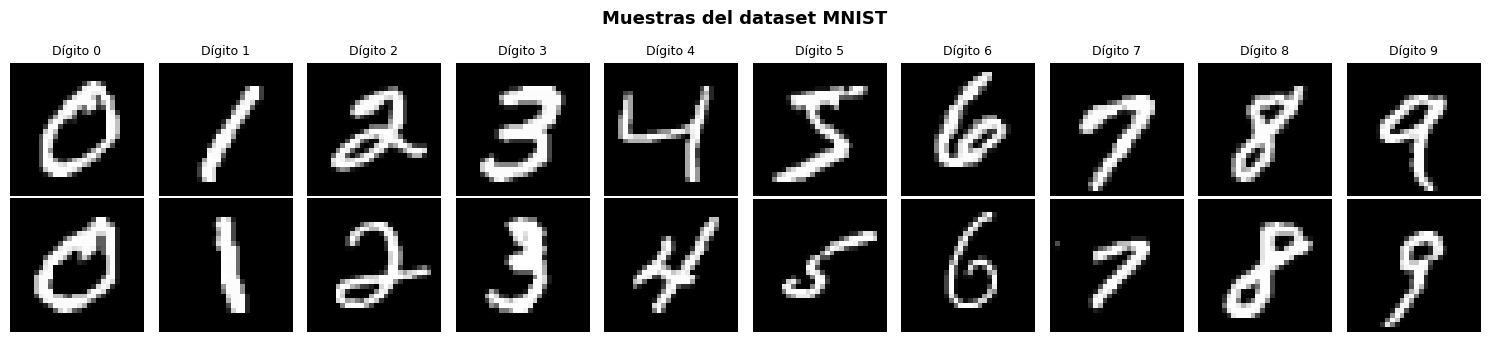

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('=== Dimensiones del dataset ===')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'Rango de píxeles: [{X_train.min()}, {X_train.max()}]')
print(f'Clases únicas: {np.unique(y_train)}')

# Visualizar muestras
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(X_train[idx], cmap='gray')
    axes[0, digit].set_title(f'Dígito {digit}', fontsize=9)
    axes[0, digit].axis('off')

    idx2 = np.where(y_train == digit)[0][1]
    axes[1, digit].imshow(X_train[idx2], cmap='gray')
    axes[1, digit].axis('off')

plt.suptitle('Muestras del dataset MNIST', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Preprocesamiento
- **Normalizar** píxeles al rango [0, 1]
- **Aplanar** las imágenes de 28×28 a vectores de 784
- **One-hot encoding** de las etiquetas

In [4]:
# Normalizar
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

# Aplanar: (60000, 28, 28) → (60000, 784)
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat  = X_test_norm.reshape(-1, 784)

# One-hot: clase 3 → [0,0,0,1,0,0,0,0,0,0]
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

# Separar validación del training
val_split = 0.1
n_val = int(len(X_train_flat) * val_split)
X_val, y_val_oh = X_train_flat[:n_val],  y_train_oh[:n_val]
X_tr,  y_tr_oh  = X_train_flat[n_val:], y_train_oh[n_val:]

print(f'Train:      {X_tr.shape}')
print(f'Validación: {X_val.shape}')
print(f'Test:       {X_test_flat.shape}')
print(f'\nEjemplo one-hot — y_train[0]={y_train[0]}: {y_train_oh[0]}')

Train:      (54000, 784)
Validación: (6000, 784)
Test:       (10000, 784)

Ejemplo one-hot — y_train[0]=5: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 4. Construir el modelo

Arquitectura:
```
Input(784) → Dense(256, ReLU) + Dropout(0.3)
           → Dense(128, ReLU) + Dropout(0.2)
           → Dense(64,  ReLU)
           → Dense(10, Softmax)
```

In [5]:
def crear_modelo():
    model = keras.Sequential([
        # Capa de entrada
        layers.Input(shape=(784,)),

        # Primera capa oculta
        layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Segunda capa oculta
        layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Tercera capa oculta
        layers.Dense(64, activation='relu', kernel_initializer='he_normal'),

        # Capa de salida (Softmax para multiclase)
        layers.Dense(10, activation='softmax')
    ], name='MNIST_Classifier')

    return model

model = crear_modelo()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "MNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

## 5. Callbacks: EarlyStopping y ReduceLROnPlateau
- **EarlyStopping**: detiene el entrenamiento si la pérdida de validación no mejora
- **ReduceLROnPlateau**: reduce el learning rate automáticamente si se estanca

In [6]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('Callbacks configurados')

Callbacks configurados


## 6. Entrenar el modelo

In [7]:
history = model.fit(
    X_tr, y_tr_oh,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val_oh),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8854 - loss: 0.3760 - val_accuracy: 0.9577 - val_loss: 0.1446 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9494 - loss: 0.1647 - val_accuracy: 0.9687 - val_loss: 0.1102 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9608 - loss: 0.1255 - val_accuracy: 0.9740 - val_loss: 0.0895 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9661 - loss: 0.1055 - val_accuracy: 0.9742 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9713 - loss: 0.0891 - val_accuracy: 0.9765 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0805 - val_accuracy: 0.9793 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0677 - 

## 7. Curvas de entrenamiento

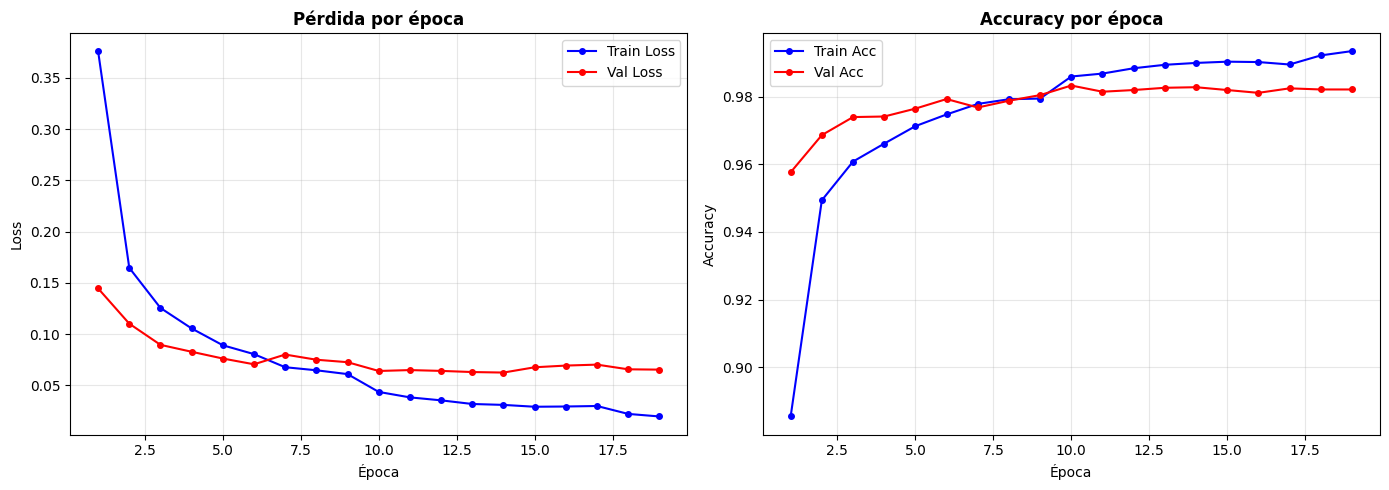

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

# Pérdida
axes[0].plot(epochs_range, history.history['loss'],     'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, history.history['val_loss'], 'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Pérdida por época', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history.history['accuracy'],     'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs_range, history.history['val_accuracy'], 'r-o', markersize=4, label='Val Acc')
axes[1].set_title('Accuracy por época', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 8. Evaluación en el conjunto de prueba

In [9]:
loss_test, acc_test = model.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f'Test Loss:     {loss_test:.4f}')
print(f'Test Accuracy: {acc_test*100:.2f}%')

Test Loss:     0.0638
Test Accuracy: 98.33%


## 9. Matriz de confusión

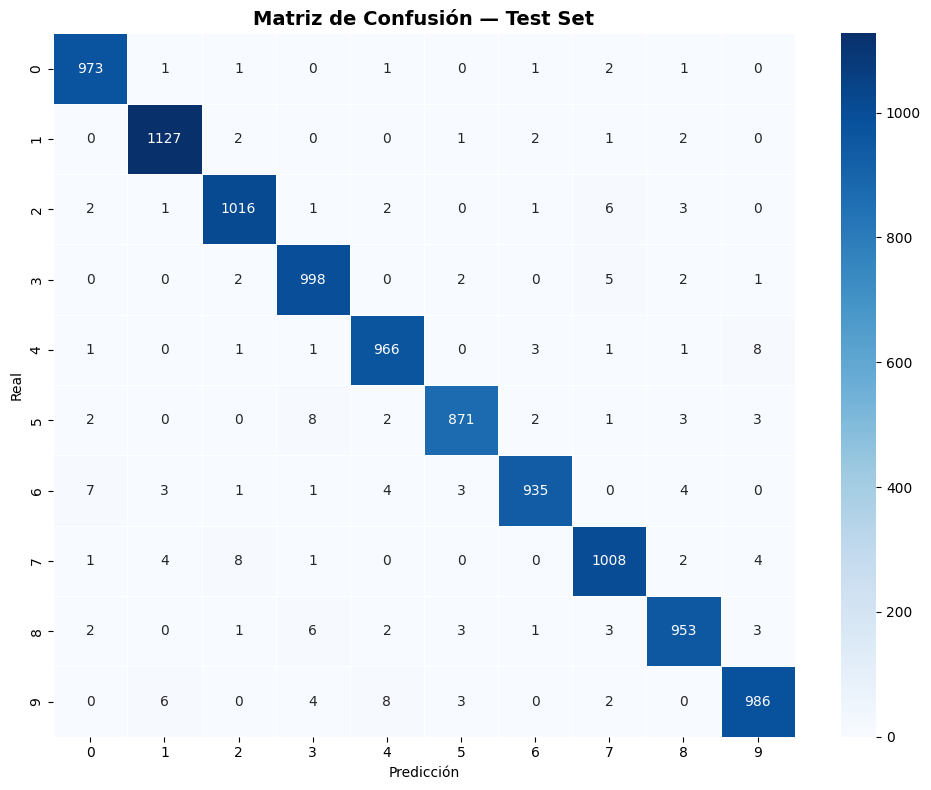


=== Reporte por clase ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [10]:
y_pred_prob = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5)
plt.title('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.tight_layout(); plt.show()

print('\n=== Reporte por clase ===')
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

## 10. Visualizar predicciones individuales

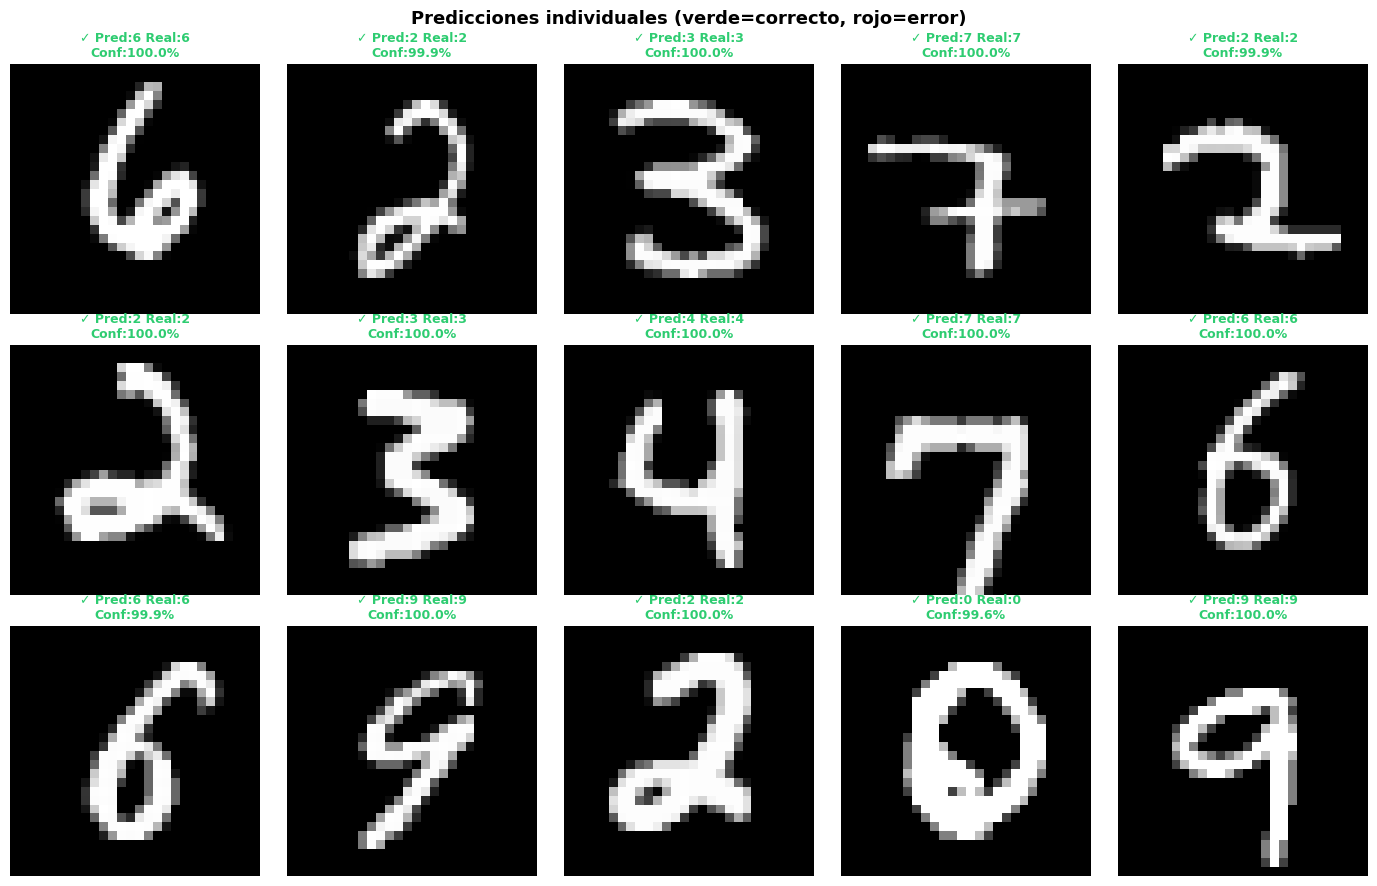

In [11]:
# Mostrar 15 predicciones aleatorias
indices = np.random.choice(len(X_test), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test[idx]
    pred = y_pred[idx]
    real = y_test[idx]
    confianza = y_pred_prob[idx][pred] * 100
    correcto = pred == real

    axes[i].imshow(img, cmap='gray')
    color = '#2ECC71' if correcto else '#E74C3C'
    simbolo = '✓' if correcto else '✗'
    axes[i].set_title(
        f'{simbolo} Pred:{pred} Real:{real}\nConf:{confianza:.1f}%',
        fontsize=9, color=color, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Predicciones individuales (verde=correcto, rojo=error)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Analizar los errores más comunes

Total de errores: 167 / 10000 (1.67%)


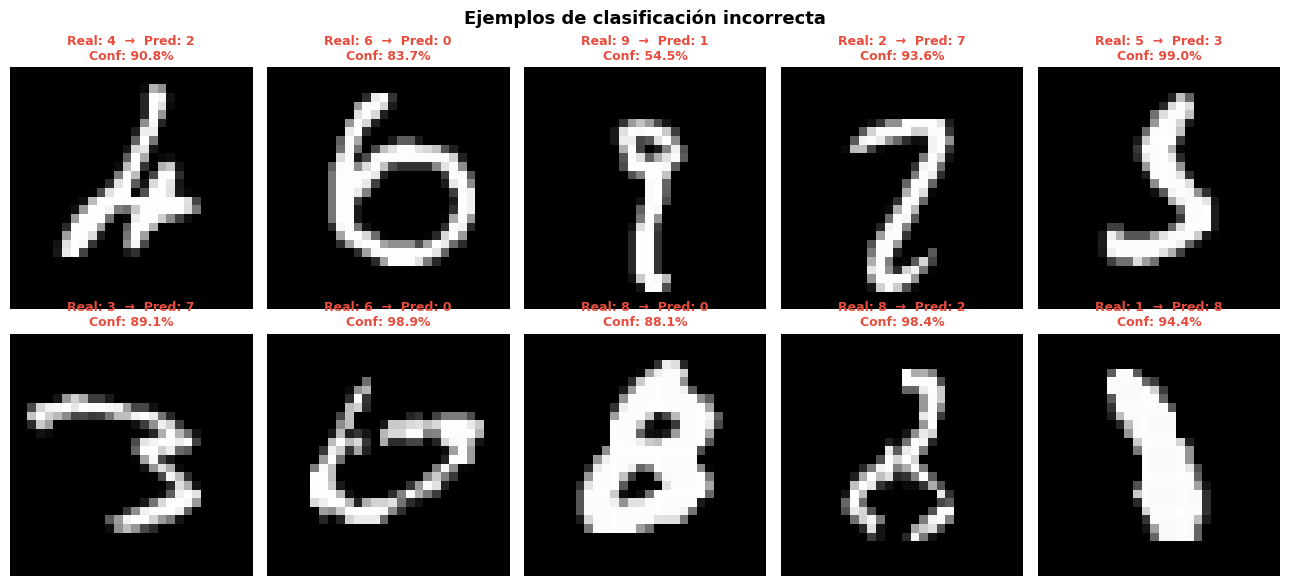

In [12]:
# Encontrar imágenes mal clasificadas
errores = np.where(y_pred != y_test)[0]
print(f'Total de errores: {len(errores)} / {len(y_test)} ({len(errores)/len(y_test)*100:.2f}%)')

# Mostrar los 10 primeros errores
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for i, idx in enumerate(errores[:10]):
    axes[i].imshow(X_test[idx], cmap='gray')
    confianza = y_pred_prob[idx][y_pred[idx]] * 100
    axes[i].set_title(
        f'Real: {y_test[idx]}  →  Pred: {y_pred[idx]}\nConf: {confianza:.1f}%',
        fontsize=9, color='#E74C3C', fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Ejemplos de clasificación incorrecta', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Guardar y cargar el modelo

In [13]:
# Guardar
model.save('modelo_mnist.keras')
print('Modelo guardado como modelo_mnist.keras')

# Cargar
model_cargado = keras.models.load_model('modelo_mnist.keras')
_, acc_cargado = model_cargado.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f'Modelo cargado — Accuracy verificado: {acc_cargado*100:.2f}%')

Modelo guardado como modelo_mnist.keras
Modelo cargado — Accuracy verificado: 98.33%


## Resumen de conceptos

| Concepto | Descripción |
|---|---|
| **Dense / Fully Connected** | Cada neurona conectada a todas las de la capa anterior |
| **ReLU** | Activación para capas ocultas; rápida y eficiente |
| **Softmax** | Activación de salida para clasificación multiclase; suma 1 |
| **Dropout** | Regularización: desactiva neuronas aleatoriamente para evitar overfitting |
| **BatchNorm** | Normaliza activaciones por mini-batch; estabiliza el entrenamiento |
| **Adam** | Optimizador adaptativo; combina momentum + RMSprop |
| **EarlyStopping** | Para el entrenamiento cuando la validación deja de mejorar |
| **Categorical CrossEntropy** | Función de pérdida para clasificación multiclase |

### Ejercicios propuestos
1. Cambia el dataset a **Fashion-MNIST** (`keras.datasets.fashion_mnist`) sin cambiar el modelo.
2. Quita las capas de **Dropout** y observa si aparece overfitting.
3. Prueba con el optimizador **SGD** con momentum en lugar de Adam.
4. Añade **data augmentation** usando `ImageDataGenerator` de Keras.
5. Convierte el modelo a **CNN** añadiendo capas `Conv2D` y `MaxPooling2D`.